# Prototype: Strict Stim Pulse Width Classification

Goal: extract pulse bursts from noisy stim edge timestamps, classify each pulse as 15 ms or 30 ms with strict tolerance, and produce all-pulse plus split alignment event outputs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ephys.src.utils.utils_IO import fetch_session_events

/Users/gabriel/lib/ephys/.venv/lib/python3.11/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # requires setuptools<82
[2026-03-13 14:44:27,908][INFO]: DataJoint 0.14.9 connected to rojasbowe@churchland-data.cmojfwfr0b9t.us-west-2.rds.amazonaws.com:3306


In [2]:
def segment_noisy_pulses(stim_timestamps, max_within_pulse_gap_s):
    ts = np.asarray(stim_timestamps, dtype=float)
    if ts.size == 0:
        return pd.DataFrame(columns=["onset_s", "offset_s", "duration_s", "n_edges"])

    ts = np.sort(ts)
    split_idx = np.where(np.diff(ts) > max_within_pulse_gap_s)[0] + 1
    bursts = np.split(ts, split_idx)

    rows = []
    for burst in bursts:
        onset = float(burst[0])
        offset = float(burst[-1])
        rows.append(
            {
                "onset_s": onset,
                "offset_s": offset,
                "duration_s": offset - onset,
                "n_edges": int(burst.size),
            }
        )

    return pd.DataFrame(rows)


def classify_pulse_widths_strict(
    durations_s, tol_s=2e-3, width_15_s=0.015, width_30_s=0.030
):
    d = np.asarray(durations_s, dtype=float)

    is_15 = np.abs(d - width_15_s) <= tol_s
    is_30 = np.abs(d - width_30_s) <= tol_s

    ambiguous = is_15 & is_30
    unclassified = ~(is_15 | is_30)

    if np.any(ambiguous) or np.any(unclassified):
        bad_mask = ambiguous | unclassified
        bad_ms = (d[bad_mask] * 1000.0).tolist()[:10]
        bad_ms_fmt = ", ".join(f"{x:.6f}" for x in bad_ms)
        print(
            "WARNING: classification had some unclassified or ambiguous pulses:\n"
            f"total={d.size}, ambiguous={int(np.sum(ambiguous))}, "
            f"unclassified={int(np.sum(unclassified))}\n"
            f"example_durations_ms=[{bad_ms_fmt}]"
        )

    # Use 'unknown' for anything that doesn't fit
    labels = np.where(is_15, "15ms", np.where(is_30, "30ms", "unknown"))
    return labels


def build_stim_alignment_events_strict(
    stim_timestamps, max_within_pulse_gap_s, first_sep_s=1.0
):
    pulse_table = segment_noisy_pulses(
        stim_timestamps, max_within_pulse_gap_s=max_within_pulse_gap_s
    )
    labels = classify_pulse_widths_strict(
        pulse_table["duration_s"].to_numpy(),
        tol_s=2e-3,
        width_15_s=0.015,
        width_30_s=0.030,
    )
    pulse_table = pulse_table.copy()
    pulse_table["class_label"] = labels

    stim_ev = pulse_table["onset_s"].to_numpy()
    stim_ev_15ms = pulse_table.loc[
        pulse_table["class_label"] == "15ms", "onset_s"
    ].to_numpy()
    stim_ev_30ms = pulse_table.loc[
        pulse_table["class_label"] == "30ms", "onset_s"
    ].to_numpy()

    def first_events(ev, sep_s):
        ev = np.asarray(ev, dtype=float)
        if ev.size == 0:
            return ev
        keep = np.r_[True, np.diff(ev) > sep_s]
        return ev[keep]

    first_stim_ev = first_events(stim_ev, first_sep_s)
    first_stim_ev_15ms = first_events(stim_ev_15ms, first_sep_s)
    first_stim_ev_30ms = first_events(stim_ev_30ms, first_sep_s)

    return {
        "stim_ev": stim_ev,
        "first_stim_ev": first_stim_ev,
        "stim_ev_15ms": stim_ev_15ms,
        "stim_ev_30ms": stim_ev_30ms,
        "first_stim_ev_15ms": first_stim_ev_15ms,
        "first_stim_ev_30ms": first_stim_ev_30ms,
        "pulse_table": pulse_table,
    }

In [3]:
subject = "GRB058"
session = "20260312_134952"

align_ev = fetch_session_events(subject, session)
stim_raw = align_ev["stim"]

prot = build_stim_alignment_events_strict(
    stim_raw,
    max_within_pulse_gap_s=0.020,
    first_sep_s=1.0,
)

stim_ev = prot["stim_ev"]
first_stim_ev = prot["first_stim_ev"]
stim_ev_15ms = prot["stim_ev_15ms"]
stim_ev_30ms = prot["stim_ev_30ms"]
first_stim_ev_15ms = prot["first_stim_ev_15ms"]
first_stim_ev_30ms = prot["first_stim_ev_30ms"]
pulse_table = prot["pulse_table"]

for k in [
    "stim_ev",
    "first_stim_ev",
    "stim_ev_15ms",
    "stim_ev_30ms",
    "first_stim_ev_15ms",
    "first_stim_ev_30ms",
    "pulse_table",
]:
    v = prot[k]
    n = len(v) if k != "pulse_table" else len(v.index)
    print(f"{k}: {n}")

total=1865, ambiguous=0, unclassified=20
example_durations_ms=[10.009756, 4.943810, 10.559072, 7.995598, 7.995598, 2.258299, 2.258445, 12.634267, 2.258458, 7.934563]
stim_ev: 1865
first_stim_ev: 228
stim_ev_15ms: 1757
stim_ev_30ms: 88
first_stim_ev_15ms: 196
first_stim_ev_30ms: 30
pulse_table: 1865


15ms: n=1757, median_ms=14.831528, mad_ms=0.122051
30ms: n=88, median_ms=29.907182, mad_ms=0.000150
unknown: n=20, median_ms=7.934563, mad_ms=2.594194

Sample unknown durations (ms):
[10.00975567  4.94380976 10.55907153  7.99559752  7.99559752  2.25829854
  2.25844494 12.63426694  2.25845837  7.93456331  7.93456248  5.12714462
 10.4984423  12.57322928  7.69042206  7.32421147  7.81249532 12.4511595
  7.32421146 12.93944026]


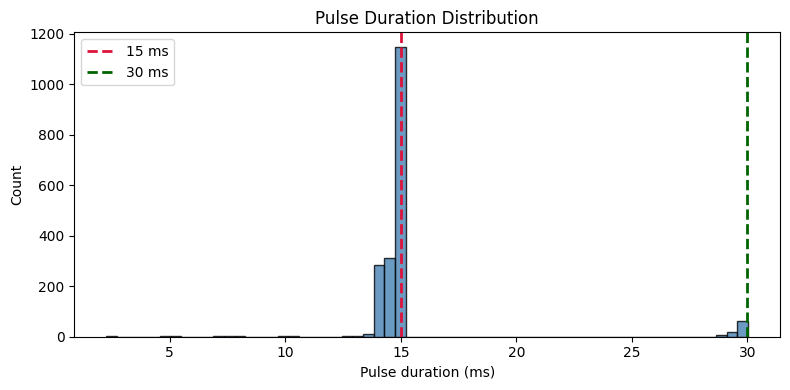

In [4]:
pt = pulse_table.copy()
pt["duration_ms"] = pt["duration_s"] * 1000.0

for cls in ["15ms", "30ms", "unknown"]:
    vals = pt.loc[pt["class_label"] == cls, "duration_ms"].to_numpy()
    if vals.size == 0:
        print(f"{cls}: n=0")
    else:
        med = float(np.median(vals))
        mad = float(np.median(np.abs(vals - med)))
        print(f"{cls}: n={vals.size}, median_ms={med:.6f}, mad_ms={mad:.6f}")

print("\nSample unknown durations (ms):")
print(pt.loc[pt["class_label"] == "unknown", "duration_ms"].head(20).to_numpy())

plt.figure(figsize=(8, 4))
plt.hist(pt["duration_ms"], bins=60, alpha=0.8, color="steelblue", edgecolor="black")
plt.axvline(15.0, color="crimson", linestyle="--", linewidth=2, label="15 ms")
plt.axvline(30.0, color="darkgreen", linestyle="--", linewidth=2, label="30 ms")
plt.xlabel("Pulse duration (ms)")
plt.ylabel("Count")
plt.title("Pulse Duration Distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
# assert len(stim_ev) == len(stim_ev_15ms) + len(stim_ev_30ms) # this won't hold if there are unknowns

for key in [
    "stim_ev",
    "first_stim_ev",
    "stim_ev_15ms",
    "stim_ev_30ms",
    "first_stim_ev_15ms",
    "first_stim_ev_30ms",
]:
    arr = np.asarray(locals()[key], dtype=float)
    assert np.all(np.diff(arr) >= 0), f"{key} is not monotonic increasing"

print("Validation passed.")

Validation passed.


Plotting 15ms examples...


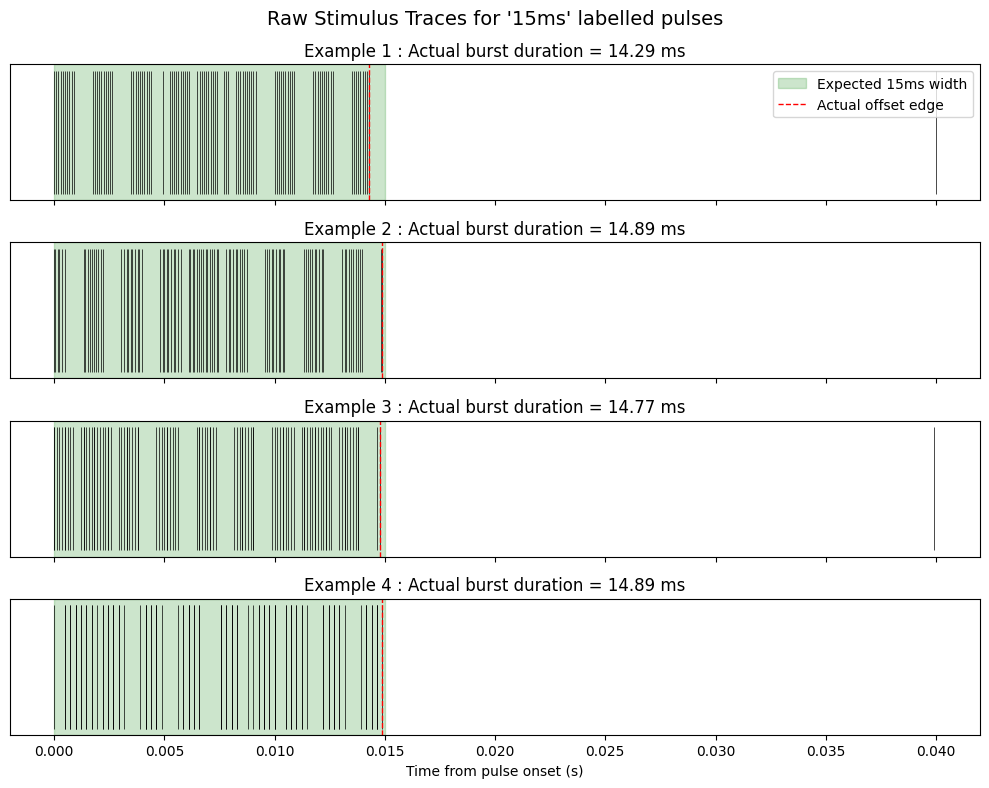


Plotting 30ms examples...


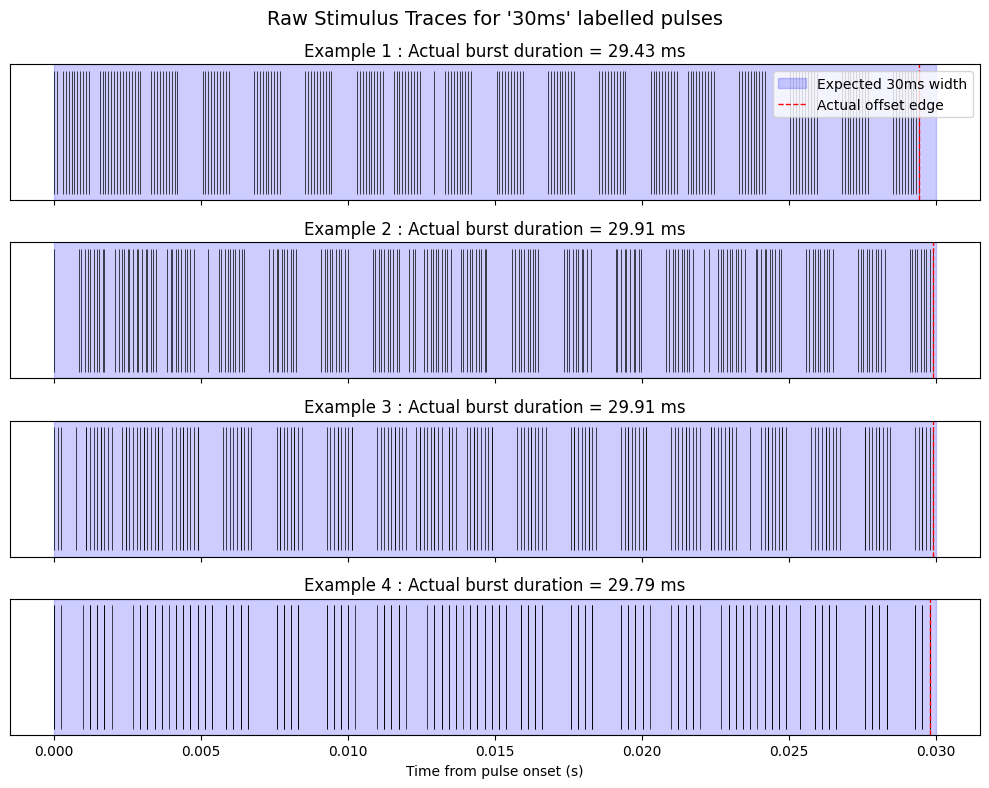


Plotting unknown examples...


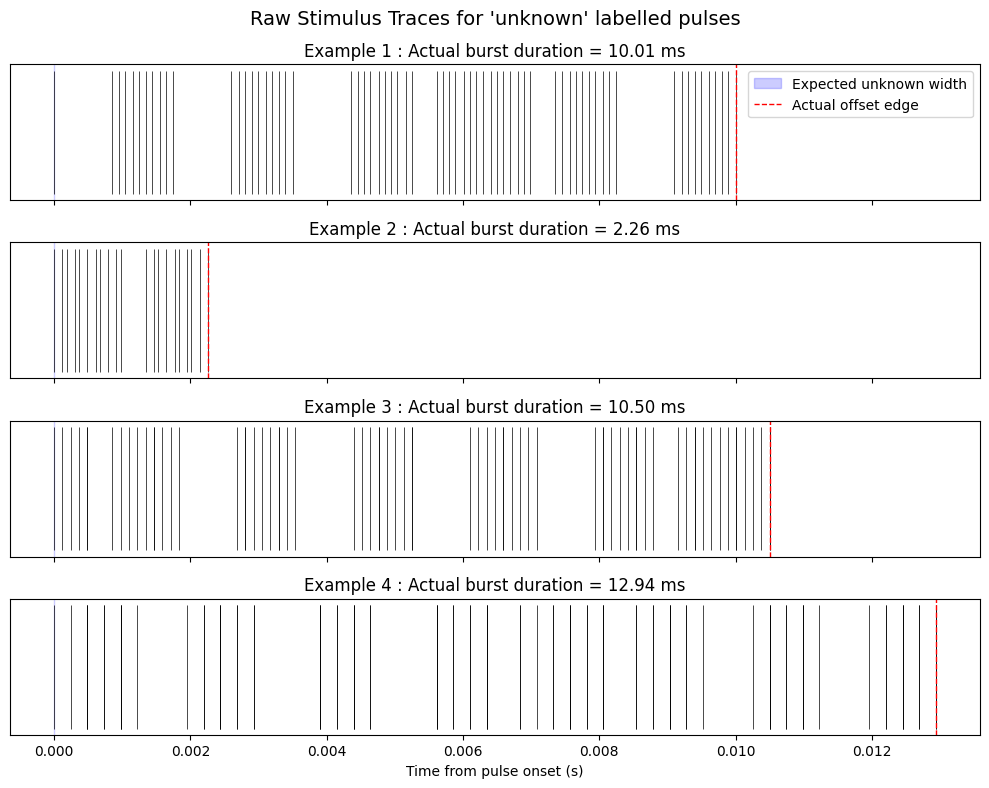

In [6]:
# Helper to create a raster plot of the raw stimulus signal around classified events
def plot_stim_pulse_examples(
    stim_timestamps, pulse_table, class_label, n_examples=5, pre_s=0.01, post_s=0.04
):
    subset = pulse_table[pulse_table["class_label"] == class_label]
    if len(subset) == 0:
        print(f"No pulses found for class: {class_label}")
        return

    # Pick a few evenly spaced examples to avoid just seeing the first few identical trials
    indices = np.linspace(0, len(subset) - 1, min(n_examples, len(subset)), dtype=int)
    example_onsets = subset.iloc[indices]["onset_s"].values

    fig, axes = plt.subplots(
        len(example_onsets), 1, figsize=(10, 2 * len(example_onsets)), sharex=True
    )
    if len(example_onsets) == 1:
        axes = [axes]

    for i, (ax, onset) in enumerate(zip(axes, example_onsets)):
        # Extract raw timestamps around the event
        window_mask = (stim_timestamps >= onset - pre_s) & (
            stim_timestamps <= onset + post_s
        )
        window_ts = stim_timestamps[window_mask]

        if len(window_ts) == 0:
            continue

        # In a generic "edge" trace, every timestamp toggles state from 0 to 1, or 1 to 0.
        # Since it's noisy and very fast, plotting a raster of edges is usually easiest.
        # Here we'll plot vertical lines for every edge timestamp
        ax.vlines(window_ts - onset, ymin=0, ymax=1, lw=0.5, color="black")

        # Shade the expected "pulse window" based on the class label
        expected_width = (
            0.015 if class_label == "15ms" else 0.030 if class_label == "30ms" else 0.0
        )
        ax.axvspan(
            0,
            expected_width,
            color="green" if class_label == "15ms" else "blue",
            alpha=0.2,
            label=f"Expected {class_label} width",
        )

        # Annotate actual duration
        actual_dur = subset.iloc[indices[i]]["duration_s"]
        ax.axvline(
            actual_dur, color="red", linestyle="--", lw=1, label="Actual offset edge"
        )

        ax.set_yticks([])
        ax.set_title(
            f"Example {i + 1} : Actual burst duration = {actual_dur * 1000:.2f} ms"
        )

        if i == 0:
            ax.legend(loc="upper right")

    axes[-1].set_xlabel("Time from pulse onset (s)")
    fig.suptitle(
        f"Raw Stimulus Traces for '{class_label}' labelled pulses", fontsize=14
    )
    fig.tight_layout()
    plt.show()


print("Plotting 15ms examples...")
plot_stim_pulse_examples(
    stim_raw, pulse_table, class_label="15ms", n_examples=4, pre_s=0.005, post_s=0.040
)

print("\nPlotting 30ms examples...")
plot_stim_pulse_examples(
    stim_raw, pulse_table, class_label="30ms", n_examples=4, pre_s=0.005, post_s=0.040
)

print("\nPlotting unknown examples...")
plot_stim_pulse_examples(
    stim_raw,
    pulse_table,
    class_label="unknown",
    n_examples=4,
    pre_s=0.005,
    post_s=0.020,
)

Plotting trials starting with 15ms pulses...


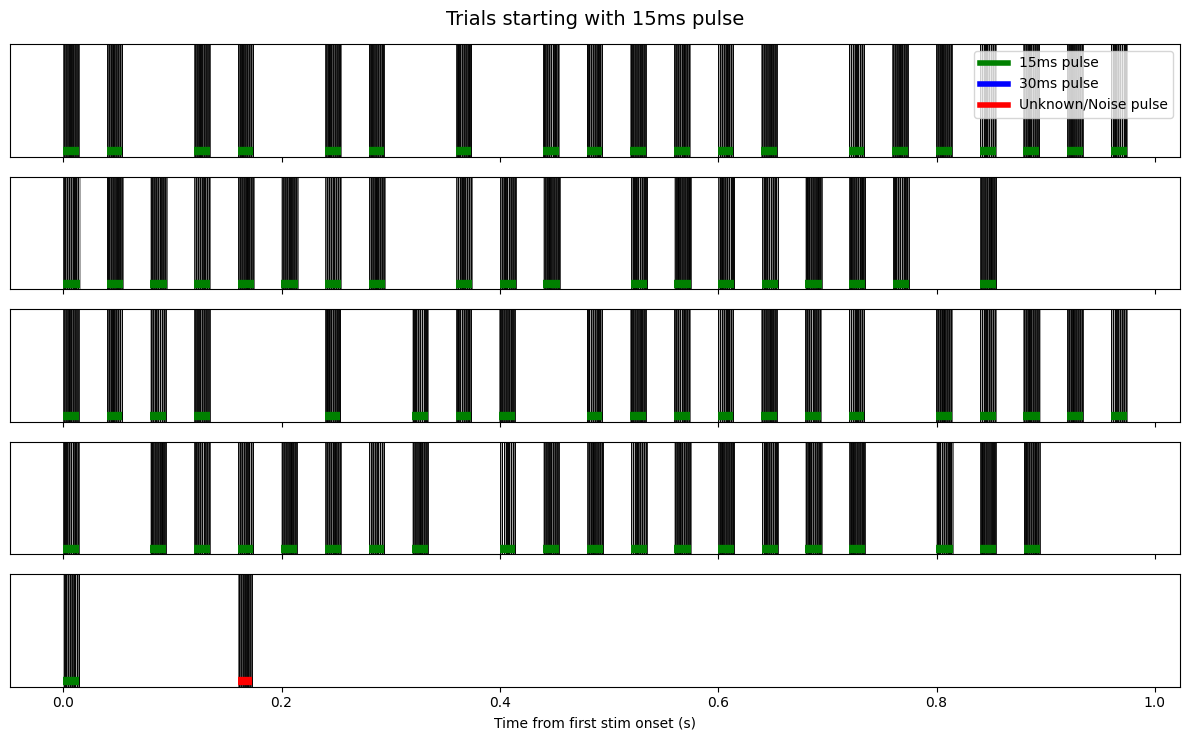


Plotting trials starting with 30ms pulses...


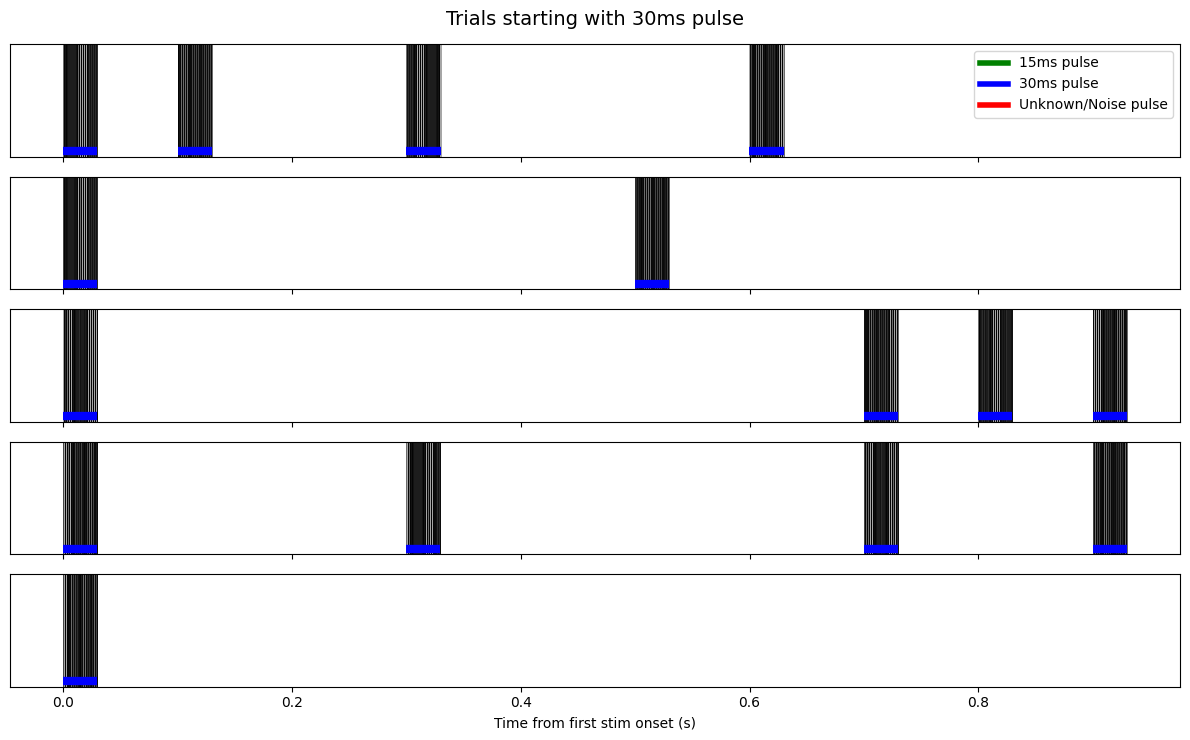

In [7]:
# Visualizing a full 1-second trial starting from the "first_stim_ev" (for both 15ms and 30ms starters)


def plot_full_trial_stims(
    stim_timestamps, pulse_table, first_stim_events, title, n_examples=5, duration_s=1.0
):
    if len(first_stim_events) == 0:
        print(f"No first stim events found for {title}")
        return

    indices = np.linspace(
        0,
        len(first_stim_events) - 1,
        min(n_examples, len(first_stim_events)),
        dtype=int,
    )
    example_onsets = first_stim_events[indices]

    fig, axes = plt.subplots(
        len(example_onsets), 1, figsize=(12, 1.5 * len(example_onsets)), sharex=True
    )
    if len(example_onsets) == 1:
        axes = [axes]

    for i, (ax, start_time) in enumerate(zip(axes, example_onsets)):
        end_time = start_time + duration_s

        # Plot raw DAQ edges (black ticks)
        # Note: at 1 second zoom, individual edges blend together into blocks, which is perfect for seeing the train
        window_mask = (stim_timestamps >= start_time - 0.05) & (
            stim_timestamps <= end_time
        )
        window_ts = stim_timestamps[window_mask]

        ax.vlines(
            window_ts - start_time, ymin=0, ymax=1, lw=0.5, color="black", alpha=0.5
        )

        # Highlight underlying extracted pulses that fall into this window
        pt_window = pulse_table[
            (pulse_table["onset_s"] >= start_time - 0.05)
            & (pulse_table["onset_s"] <= end_time)
        ]
        for _, row in pt_window.iterrows():
            c = row["class_label"]
            color = "green" if c == "15ms" else "blue" if c == "30ms" else "red"
            # draw a colored bar for the pulse width at the bottom of the axis
            ax.hlines(
                0.05,
                row["onset_s"] - start_time,
                row["offset_s"] - start_time,
                color=color,
                lw=6,
            )

        ax.set_yticks([])
        ax.set_ylim(0, 1)

    axes[-1].set_xlabel("Time from first stim onset (s)")

    # Custom legend
    from matplotlib.lines import Line2D

    custom_lines = [
        Line2D([0], [0], color="green", lw=4),
        Line2D([0], [0], color="blue", lw=4),
        Line2D([0], [0], color="red", lw=4),
    ]
    axes[0].legend(
        custom_lines,
        ["15ms pulse", "30ms pulse", "Unknown/Noise pulse"],
        loc="upper right",
    )

    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    plt.show()


print("Plotting trials starting with 15ms pulses...")
plot_full_trial_stims(
    stim_raw,
    pulse_table,
    first_stim_ev_15ms,
    title="Trials starting with 15ms pulse",
    n_examples=5,
    duration_s=1.0,
)

print("\nPlotting trials starting with 30ms pulses...")
plot_full_trial_stims(
    stim_raw,
    pulse_table,
    first_stim_ev_30ms,
    title="Trials starting with 30ms pulse",
    n_examples=5,
    duration_s=1.0,
)